# Image deconvolution using the time binned data and local coordinates for the CDS

updated on 2025-11-07

## Overview

This notebook demonstrates an **alternative image reconstruction approach** that differs from the default analysis method in COSIpy.

### Key differences from the default method:

**Default approach:**
- The Compton Data Space (CDS) is defined in **Galactic coordinates**
- Uses a response matrix that has been convolved over the spacecraft's attitude changes to transform from detector to Galactic coordinates

**This approach (time-binned + local coordinates):**
- The Compton Data Space (CDS) is defined in **detector local coordinates**
- Accounts for the continuous motion of celestial sources in the detector frame
- To handle this motion, the observation is divided into **short time bins** where the source movement is negligible

### Data used in this example:

Using the **GRB simulation data created for DC3**, we demonstrate the image analysis capability of this time-binned local coordinate approach.

In [1]:
import logging
import sys
logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))

In [2]:
from histpy import Histogram, HealpixAxis, Axis, Axes
from mhealpy import HealpixMap
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic

from cosipy.response import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.data_io import UnBinnedData, BinnedData
from cosipy.image_deconvolution import CoordsysConversionMatrix, TimeBinnedExposureTable, DataIF_COSI_DC2, ImageDeconvolution
from cosipy.util import fetch_wasabi_file

# cosipy uses astropy units
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table
from astropy.io import fits
from scoords import Attitude, SpacecraftFrame

#3ML is needed for spectral modeling
from threeML import *
from astromodels import Band

#Other standard libraries
import numpy as np
import matplotlib.pyplot as plt
import os

import healpy as hp
from tqdm.autonotebook import tqdm

%matplotlib inline

14:09:17 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=817660;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=560856;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=598740;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=379329;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=268768;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=491218;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=397101;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=717990;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=205860;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=350381;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#40\40]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=410568;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=247777;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=843187;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=248630;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=515761;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=723277;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=798405;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=222645;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=386459;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=281724;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

# 0. Prepare the data
Before running the notebook, please download the files needed for this analysis. You can get them from wasabi. 

The data reduction from raw fits files may take hours depending on your environment. So we can skip this process.
Please download the following data files and then run the following cells.

From wasabi
- cosi-pipeline-public/COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5
- cosi-pipeline-public/COSI-SMEX/DC3/Data/Sources/GRB_MGF070201_3months_unbinned_data_filtered_with_SAAcut.fits.gz
- cosi-pipeline-public/COSI-SMEX/DC3/Data/Backgrounds/Ge/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz
    - In this notebook, only the albedo gamma-ray background is considered for a tutorial.
    - If you want to consider all of the background components, please combined them all and retry the analysis.
- cosi-pipeline-public/COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits

From docs/tutorials/image_deconvolution/optional/time_binned_data_w_local_coordinate
- inputs_GRB.yaml

You can download the data and detector response from wasabi. You can skip the following cells if you already have downloaded the files.

In [3]:
# Response file:
# wasabi path: COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5
# File size: 215M
fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5', checksum = '7121f094be50e7bfe9b31e53015b0e85')

A file named ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5 already exists with the specified checksum (7121f094be50e7bfe9b31e53015b0e85). Skipping.


In [4]:
# Source file (GRB/MGF)
# wasabi path: COSI-SMEX/DC3/Data/Sources/GRB_MGF070201_3months_unbinned_data_filtered_with_SAAcut.fits.gz
# File size: 167K
fetch_wasabi_file('COSI-SMEX/DC3/Data/Sources/GRB_MGF070201_3months_unbinned_data_filtered_with_SAAcut.fits.gz', checksum = '10c2e09e188a8b7b4042c167b80e2133')

A file named GRB_MGF070201_3months_unbinned_data_filtered_with_SAAcut.fits.gz already exists with the specified checksum (10c2e09e188a8b7b4042c167b80e2133). Skipping.


In [5]:
# Background file (albedo gamma):
# wasabi path: COSI-SMEX/DC3/Data/Backgrounds/Ge/aAlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz
# File size: 2.7G
fetch_wasabi_file('COSI-SMEX/DC3/Data/Backgrounds/Ge/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz', checksum = '191a451ee597fd2e4b1cf237fc72e6e2')

A file named AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz already exists with the specified checksum (191a451ee597fd2e4b1cf237fc72e6e2). Skipping.


In [6]:
# Orientation file:
# wasabi path: COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits
# File size: 1.1G
fetch_wasabi_file('COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits', checksum = 'a9163ab4852c427d09bcfe02df71173a')         

A file named DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits already exists with the specified checksum (b87fd41b6c28a5c0c51448ce2964e57c). Skipping.


## Load the response and orientation files

<span style="color:red"> please modify "path_data" corresponding to your environment.</span>

In [7]:
path_data = "./"

In [8]:
%%time

ori_filepath = path_data + "DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits"
orientation = SpacecraftHistory.open(ori_filepath)

CPU times: user 13.1 s, sys: 863 ms, total: 14 s
Wall time: 14 s


In [9]:
full_detector_response_filename = path_data + "ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
full_detector_response = FullDetectorResponse.open(full_detector_response_filename)

nside_local = full_detector_response.nside
npix_local = hp.nside2npix(nside_local)

nside_local, npix_local

(8, 768)

In [10]:
full_detector_response

FILENAME: '/Users/yoneda/Work/Exp/COSI/cosipy-2/data_challenge/DC3/Data/Responses/new_format/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 768
    NSIDE: 8
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 30
    EDGES: [0.0 deg, 6.0 deg, 12.0 deg, 18.0 deg, 2

# 1. Analyze the orientation file

Here the orientation file is analyzed to define the indices of the timing binning.

## What we do in this section:

1. **Define the time range of interest**: 
   - We specify the start time (`tstart`) and end time (`tstop`) of the GRB event
   - In this example: ~1 second duration GRB

2. **Create time bins**:
   - Divide the observation into short time intervals where source motion in the detector frame is negligible
   - Here we use `np.linspace(tstart, tstop, 3)` to create **2 time bins** (defined by 3 edges)

3. **Generate exposure table**:
   - `TimeBinnedExposureTable.from_orientation()` reads the spacecraft orientation file
   - For each time bin, it calculates:
     - Average pointing direction (`zpointing_averaged`)
     - Earth zenith direction in spacecraft coordinates
     - Other spacecraft attitude information needed for coordinate transformation

This exposure table will be used to transform between detector local coordinates and sky coordinates (Galactic) for each time bin.

In [11]:
tstart = 1835537496.0   # start time of the GRB
tstop  = 1835537497.022 # end time of the GRB

tedges = np.linspace(tstart, tstop, 3)

tstart_list = Time(tedges[:-1], scale='utc', format='unix')
tstop_list  = Time(tedges[1:], scale='utc', format='unix')

tstart_list, tstop_list # here we bin the time into two bins

(<Time object: scale='utc' format='unix' value=[1.8355375e+09 1.8355375e+09]>,
 <Time object: scale='utc' format='unix' value=[1.8355375e+09 1.8355375e+09]>)

In [12]:
exposure_table = TimeBinnedExposureTable.from_orientation(orientation, tstart_list = tstart_list, tstop_list = tstop_list)
exposure_table

,time_binning_index,tstart,tstop,zpointing,xpointing,zpointing_averaged,xpointing_averaged,earth_zenith,altitude,livetime,total_livetime,num_pointings
0,0,1.835537e+09,1.835537e+09,"[[120.09908671309904, -40.94414249354014]]","[[120.09908671309904, 49.05585750645985]]","[120.09908671309904, -40.94414249354014]","[120.09908671309904, 49.055857506459866]","[[117.88760413850812, -62.7795101209547]]",[527.5928237241633],[0.5110001564025879],0.511,1
1,1,1.835537e+09,1.835537e+09,"[[120.13588940501828, -40.94544431537452], [12...","[[120.13589021330336, 49.054555684625484], [12...","[120.1374056560415, -40.94549817041093]","[120.13740649326157, 49.054502271075165]","[[117.95296911630932, -62.78184104363673], [11...","[527.5947063200742, 527.5965078637616]","[0.4889998435974121, 0.02200007438659668]",0.511,2


# 2. Calculate the coordinate conversion matrix

## What is the coordinate conversion matrix?

The `CoordsysConversionMatrix` transforms **all-sky images in Galactic coordinates** into **detector local coordinates** for each time bin.

## What we do in this section:

1. **Calculate the conversion matrix for each time bin**:
   - Uses the exposure table created in Section 1
   - For each time bin, calculates the transformation matrix based on spacecraft attitude
   - This matrix converts sky models (in Galactic coordinates) to detector frame (local coordinates)
   - `use_averaged_pointing = True`: Uses the averaged pointing direction within each time bin

2. **Save and load the matrix**:
   - The matrix is saved as `ccm_time.hdf5` for reuse
   - This saves computation time for repeated analyses

3. **Check exposure maps**:
   - `calc_exposure_map()` computes the effective exposure for each sky pixel
   - Takes into account:
     - Detector response
     - Spacecraft pointing direction
     - Observation time in each bin

In [13]:
%%time

nside_model = nside_local

coordsys_conv_matrix = CoordsysConversionMatrix.from_exposure_table(exposure_table, full_detector_response, nside_model = nside_model, use_averaged_pointing = True)

  0%|          | 0/2 [00:00<?, ?it/s]

CPU times: user 1.02 s, sys: 27.3 ms, total: 1.05 s
Wall time: 1.05 s


You can save CoordsysConversionMatrix as a hdf5 file.

In [14]:
coordsys_conv_matrix.write("ccm_time.hdf5", overwrite = True)

You can also read the saved file.

In [15]:
coordsys_conv_matrix = CoordsysConversionMatrix.open("ccm_time.hdf5")

## check exposure maps

In [16]:
exposure_map = coordsys_conv_matrix.calc_exposure_map(full_detector_response)
exposure_map

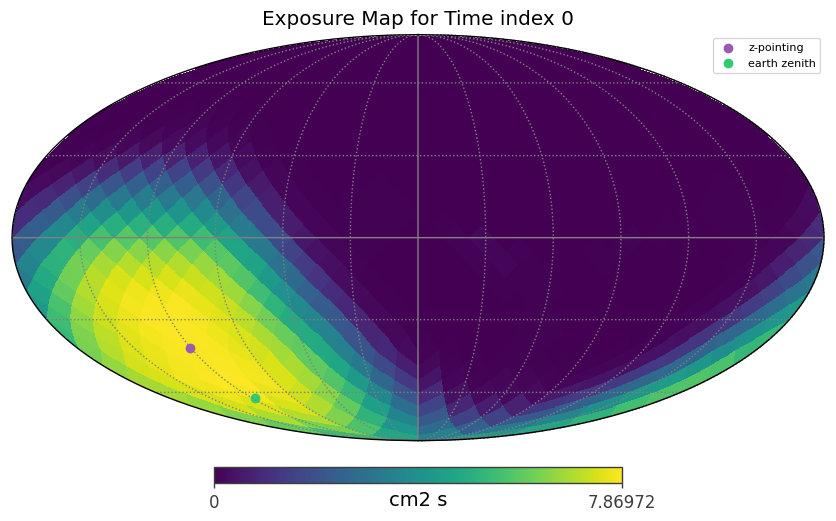

In [17]:
time_index = 0
energy_index = 0

zpointing_averaged = exposure_table.iloc[time_index]['zpointing_averaged']
earth_zenith = exposure_table.iloc[time_index]['earth_zenith'][0]

hp.mollview(exposure_map.slice[{'Time': time_index, 'Ei': energy_index}].project('lb').contents, 
            unit = f'{exposure_map.unit}', title = f'Exposure Map for Time index {time_index}')
hp.projscatter(zpointing_averaged[0], zpointing_averaged[1], lonlat = True, label = 'z-pointing')
hp.projscatter(earth_zenith[0], earth_zenith[1], lonlat = True, label = 'earth zenith')
hp.graticule(color='gray', dpar = 30)
plt.legend()

# 3. Prepare data

## Data binning strategy

In this section, we bin the unbinned event data into histograms using the time-binned approach with local coordinates.

### Key parameters for binning:

1. **Time binning**:
   - Uses the time bins defined in Section 1 (`tstart_list`, `tstop_list`)
   - Events are separated into each time bin

2. **Spatial binning (PsiChi)**:
   - `psichi_binning = 'local'`: **Critical parameter!**
   - Bins the Compton Data Space in **detector local coordinates** (not Galactic)
   - PsiChi represents the location in Compton Data Space (scatter direction)

3. **Data types**:
   - **Signal data**: GRB events (`GRB_MGF070201_3months_unbinned_data_filtered_with_SAAcut.fits.gz`)
   - **Background data**: Albedo gamma-rays from Earth's atmosphere (`AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz`)

### Process:

1. Load unbinned data from FITS files
2. Use `exposure_table.get_binned_data()` to bin events:
   - Automatically assigns events to appropriate time bins based on TimeTag
   - Bins in Em (measured energy), Phi (Compton angle), and PsiChi (scatter direction in local coordinates)
3. Combine signal and background: `binned_event = binned_signal + binned_bkg`
4. Save binned data as HDF5 files for image deconvolution

### Important notes:

- `sparse = False`: Uses dense arrays (not sparse) for histograms
- The method assumes TimeTags are sorted in ascending order
- TimeTags must match the time format ('unix') and scale ('utc') of the exposure table

In [18]:
%%time

signal_filepath = "GRB_MGF070201_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

unbinned_signal = UnBinnedData(input_yaml = "inputs_GRB.yaml")

unbinned_signal.cosi_dataset = unbinned_signal.get_dict_from_fits(signal_filepath)

binned_signal = exposure_table.get_binned_data(unbinned_signal, psichi_binning = 'local', sparse = False)

This method assumes that TimeTags are sorted in ascending order.
This method assumes that TimeTags have the same time format ('unix') and scale ('utc') as tstart/tstop in the exposure table.
CPU times: user 797 ms, sys: 5.42 ms, total: 802 ms
Wall time: 801 ms


In [19]:
%%time

bkg_filepath = "AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

unbinned_bkg = UnBinnedData(input_yaml = "inputs_GRB.yaml")

unbinned_bkg.cosi_dataset = unbinned_bkg.get_dict_from_fits(bkg_filepath)

binned_bkg = exposure_table.get_binned_data(unbinned_bkg, psichi_binning = 'local', sparse = False)

This method assumes that TimeTags are sorted in ascending order.
This method assumes that TimeTags have the same time format ('unix') and scale ('utc') as tstart/tstop in the exposure table.
CPU times: user 18.4 s, sys: 2.02 s, total: 20.4 s
Wall time: 20.6 s


Sum up the signal and background data

In [20]:
binned_event = binned_signal + binned_bkg

Save them

In [21]:
binned_bkg.write(path_data + "GRB_scatt_bkg.hdf5")
binned_signal.write(path_data + "GRB_scatt_signal.hdf5")
binned_event.write(path_data + "GRB_scatt_event.hdf5")

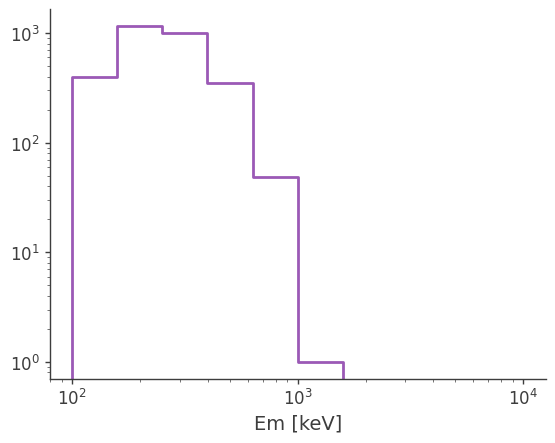

In [22]:
binned_signal.project('Em').draw()
plt.xscale('log')
plt.yscale('log')

## 4. Imaging deconvolution

### Brief overview of the image deconvolution

Basically, we have to maximize the following likelihood function

$$
\log L = \sum_i X_i \log \epsilon_i - \sum_i \epsilon_i
$$

$X_i$: detected counts at $i$-th bin ( $i$ : index of the Compton Data Space)

$\epsilon_i = \sum_j R_{ij} \lambda_j + b_i$ : expected counts ( $j$ : index of the model space)

$\lambda_j$ : the model map (basically gamma-ray flux at $j$-th pixel)

$b_i$ : the background at $i$-th bin

$R_{ij}$ : the response matrix

Since we have to optimize the flux in each pixel, and the number of parameters is large, we adopt an iterative approach to find a solution of the above equation. The simplest one is the ML-EM (Maximum Likelihood Expectation Maximization) algorithm. It is also known as the Richardson-Lucy algorithm.

$$
\lambda_{j}^{k+1} = \lambda_{j}^{k} + \delta \lambda_{j}^{k}
$$
$$
\delta \lambda_{j}^{k} = \frac{\lambda_{j}^{k}}{\sum_{i} R_{ij}} \sum_{i} \left(\frac{ X_{i} }{\epsilon_{i}} - 1 \right) R_{ij} 
$$

We refer to $\delta \lambda_{j}^{k}$ as the delta map.

As for now, the two improved algorithms are implemented in COSIpy.

- Accelerated ML-EM algorithm (Knoedlseder+99)

$$
\lambda_{j}^{k+1} = \lambda_{j}^{k} + \alpha^{k} \delta \lambda_{j}^{k}
$$
$$
\alpha^{k} < \mathrm{max}(- \lambda_{j}^{k} / \delta \lambda_{j}^{k})
$$

Practically, in order not to accelerate the algorithm excessively, we set the maximum value of $\alpha$ ($\alpha_{\mathrm{max}}$). Then, $\alpha$ is calculated as:

$$
\alpha^{k} = \mathrm{min}(\mathrm{max}(- \lambda_{j}^{k} / \delta \lambda_{j}^{k}), \alpha_{\mathrm{max}})
$$

- Noise damping using gaussian smoothing (Knoedlseder+05, Siegert+20)

$$
\lambda_{j}^{k+1} = \lambda_{j}^{k} + \alpha^{k} \left[ w_j \delta \lambda_{j}^{k} \right]_{\mathrm{gauss}}
$$
$$
w_j = \left(\sum_{i} R_{ij}\right)^\beta
$$

$\left[ ... \right]_{\mathrm{gauss}}$ means that the differential image is smoothed by a gaussian filter.

## 4-1. Prepare DataInterface containing all necessary datasets

In [23]:
%%time

#  background 
data_bkg = BinnedData("inputs_GRB.yaml")
data_bkg.load_binned_data_from_hdf5("GRB_scatt_bkg.hdf5")

##  signal + background
data_event = BinnedData("inputs_GRB.yaml")
data_event.load_binned_data_from_hdf5("GRB_scatt_event.hdf5")

data_interface = DataIF_COSI_DC2.load(name = "GRB",
                                      event_binned_data = data_event.binned_data,
                                      dict_bkg_binned_data = {"albedo": data_bkg.binned_data},
                                      rsp = full_detector_response,
                                      coordsys_conv_matrix=coordsys_conv_matrix)

Loading the response matrix onto your computer memory...
Finished
... checking the axis Time of the event and background files...
    --> pass (edges)
... checking the axis Em of the event and background files...
    --> pass (edges)
... checking the axis Phi of the event and background files...
    --> pass (edges)
... checking the axis PsiChi of the event and background files...
    --> pass (edges)
...checking the axis Em of the event and response files...
    --> pass (edges)
...checking the axis Phi of the event and response files...
    --> pass (edges)
...checking the axis PsiChi of the event and response files...
    --> pass (edges)
The axes in the event and background files are redefined. Now they are consistent with those of the response file.
Calculating an exposure map...
Finished...
CPU times: user 9.62 s, sys: 2.22 s, total: 11.8 s
Wall time: 12.2 s


### 4-2. Initialize the instance of the image deconvolution class

First, we prepare an instance of the ImageDeconvolution class and then register the dataset and parameters for the deconvolution. After that, you can start the calculation.

<span style="color:red"> please modify this parameter_filepath corresponding to your environment.</span>

In [48]:
parameter_filepath = "imagedeconvolution_parfile_scatt_GRB.yml"

In [49]:
image_deconvolution = ImageDeconvolution()

# set data_interface to image_deconvolution
image_deconvolution.set_dataset([data_interface])

# set a parameter file for the image deconvolution
image_deconvolution.read_parameterfile(parameter_filepath)

### Initialize image_deconvolution

In this process, a model map is defined following the input parameters, and it is initialized. Also, it prepares ancillary data for the image deconvolution, e.g., the expected counts with the initial model map, gaussian smoothing filter etc.

I describe parameters in the parameter file.

#### model_definition:class

Specify the name of the image class that will be used in the image deconvolution. As for now, it should be "AllSkyImage".

#### model_definition:property

| Name | Unit | Description | Notes |
| :---: | :---: | :---: | :---: |
| coordinate | str | the coordinate system of the model map | As for now, it must be 'galactic' |
| nside | int | NSIDE of the model map | it must be the same as NSIDE of 'lb' axis of the coordinate conversion matrix|
| scheme | str | SCHEME of the model map | As for now, it must be 'ring' |
| energy_edges:value | list of float | The definition of the energy bins of the model map | As for now, it must be the same as that of the response matrix |
| energy_edges:unit | str | The physical unit of the above list | In most of cases, it is keV. |
| unit | str | The physical unit of the image | As for now, it should be ""cm-2 s-1 sr-1" |

#### model_definition:initialization

| Name | Unit | Description | Notes |
| :---: | :---: | :---: | :---: |
| algorithm | str | the method name to initialize the model map | As for now, only 'flat' can be used |
| parameter_flat:value | list of float | the list of photon fluxes for each energy band | the length of the list should be the same as the length of "energy_edges" - 1 |
| parameter_flat:unit | str | The physical unit of the above list | As for now, it should be ""cm-2 s-1 sr-1" |

#### deconvolution

| Name | Unit | Description | Notes |
| :---: | :---: | :---: | :---: |
|algorithm | str | the name of the image deconvolution algorithm| As for now, only 'RL' is supported |
|||||
|parameter_RL:iteration_max | int | The maximum number of the iteration | |
|parameter_RL:acceleration:activate | bool | whether the accelerated ML-EM algorithm (Knoedlseder+99) is used | |
|parameter_RL:acceleration:alpha_max | float | the maximum value for the acceleration parameter | |
|parameter_RL:response_weighting:activate | bool | whether a delta map is renormalized based on the exposure time on each pixel, namely $w_j = (\sum_{i} R_{ij})^{\beta}$ (see Knoedlseder+05, Siegert+20) | |
|parameter_RL:response_weighting:index | float | $\beta$ in the above equation | |
|parameter_RL:smoothing:activate | bool | whether a Gaussian filter is used (see Knoedlseder+05, Siegert+20)  | |
|parameter_RL:smoothing:FWHM:value | float | the FWHM of the Gaussian in the filter | |
|parameter_RL:smoothing:FWHM:unit | str | the unit of the above value. deg. or rad. | |
|parameter_RL:background_normalization:activate | bool | whether the background normalization factor is optimized at each iteration | As for now, the single background normalization factor is used in all of the bins |
|parameter_RL:background_normalization:range | list of float | the range of the normalization factor | should be positive |
|parameter_RL:stopping_criteria:statistics | str | the statistics to be checked | In most of cases, it is "log-likelihood" |
|parameter_RL:stopping_criteria:threshold | float | the iteration is terminated when the increase of the selected statistics is below this value |  |
|parameter_RL:save_results:activate | bool | whether an updated model map, detal map, likelihood etc. are saved after the image deconvolution | |
|parameter_RL:save_results:directory | bool | the directory where the files are saved | |
|parameter_RL:save_results:only_final_result | bool | If True, only the result after the last iteration is saved | |

In [50]:
image_deconvolution.initialize()

#### Initialization Starts ####
<< Instantiating the model class AllSkyImage >>
---- parameters ----
coordinate: galactic
energy_edges:
  unit: keV
  value:
  - 100.0
  - 158.489
  - 251.189
  - 398.107
  - 630.957
  - 1000.0
  - 1584.89
  - 2511.89
  - 3981.07
  - 6309.57
  - 10000.0
nside: 8
scheme: ring
unit: cm-2 s-1 sr-1

<< Setting initial values of the created model object >>
---- parameters ----
algorithm: flat
parameter:
  unit: cm-2 s-1 sr-1
  value:
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6

<< Registering the deconvolution algorithm >>
Gaussian filter with FWHM of 2.0 deg will be applied to delta images ...
---- parameters ----
algorithm: RL
parameter:
  acceleration:
    activate: true
    alpha_max: 10.0
  background_normalization_optimization:
    activate: true
    range:
      albedo:
      - 0.01
      - 10.0
  iteration_max: 10
  response_weighting:
    activate: true
    index: 0.5
  save_results:
    activate: false
 

### (You can change the parameters as follows)

Note that when you modify the parameters, do not forget to run "initialize" again!

In [63]:
image_deconvolution.override_parameter("deconvolution:parameter:iteration_max = 200")
image_deconvolution.override_parameter("deconvolution:parameter:background_normalization_optimization:activate = False") # in this case, the total counts of the background model is zero. So, here we don't fit the bkg normalization.
image_deconvolution.override_parameter("deconvolution:parameter:acceleration:alpha_max = 10")
image_deconvolution.override_parameter("deconvolution:parameter:smoothing:FWHM:value = 10.0")

image_deconvolution.initialize()

#### Initialization Starts ####
<< Instantiating the model class AllSkyImage >>
---- parameters ----
coordinate: galactic
energy_edges:
  unit: keV
  value:
  - 100.0
  - 158.489
  - 251.189
  - 398.107
  - 630.957
  - 1000.0
  - 1584.89
  - 2511.89
  - 3981.07
  - 6309.57
  - 10000.0
nside: 8
scheme: ring
unit: cm-2 s-1 sr-1

<< Setting initial values of the created model object >>
---- parameters ----
algorithm: flat
parameter:
  unit: cm-2 s-1 sr-1
  value:
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6
  - 1e-6

<< Registering the deconvolution algorithm >>
Gaussian filter with FWHM of 10.0 deg will be applied to delta images ...
---- parameters ----
algorithm: RL
parameter:
  acceleration:
    activate: true
    alpha_max: 10
  background_normalization_optimization:
    activate: false
    range:
      albedo:
      - 0.01
      - 10.0
  iteration_max: 200
  response_weighting:
    activate: true
    index: 0.5
  save_results:
    activate: false


## 4-3. Start the image deconvolution

**On a MacBook Pro with M1 Max and 64 GB memory, it takes about 24 min for 30 iterations.**

In [65]:
%%time

image_deconvolution.run_deconvolution()

#### Image Deconvolution Starts ####
<< Initialization >>
The response weighting filter was calculated.
The expected count histograms were calculated with the initial model map.


  0%|          | 0/200 [00:00<?, ?it/s]

## Iteration 1/200 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
  alpha: 10
  background_normalization: {'albedo': 1.0}
  log-likelihood: [<Quantity -25522.46933708>]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 2/200 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>


...

<< Registering Result >>
  alpha: 1.0
  background_normalization: {'albedo': 1.0}
  log-likelihood: [<Quantity -12563.17767987>]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 199/200 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
  alpha: 1.0
  background_normalization: {'albedo': 1.0}
  log-likelihood: [<Quantity -12563.10822507>]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 200/200 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
  alpha: 1.0
  background_normalization: {'albedo': 1.0}
  log-likelihood: [<Quantity -12563.03921368>]
<< Checking Stopping Criteria >>
--> Stop
<< Finalization >>
#### Image Deconvolution Finished ####
CPU times: user 31min 32s, sys: 2min 52s, total: 34min 24s
Wall time: 3min 37s


In [66]:
image_deconvolution.results

[{'iteration': 1,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x3f2fab640>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x3f3575450>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x3f35757b0>,
  'background_normalization': {'albedo': 1.0},
  'alpha': 10,
  'log-likelihood': [<Quantity -25522.46933708>]},
 {'iteration': 2,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x3f3577dc0>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x3f35772b0>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x3f35778e0>,
  'background_normalization': {'albedo': 1.0},
  'alpha': <Quantity 1.12666918>,
  'log-likelihood': [<Quantity -14216.25210471>]},
 {'iteration': 3,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x3f35757e0>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSk

## 5. Analyze the results
Examples to see/analyze the results are shown below.

### Log-likelihood

Plotting the log-likelihood vs the number of iterations

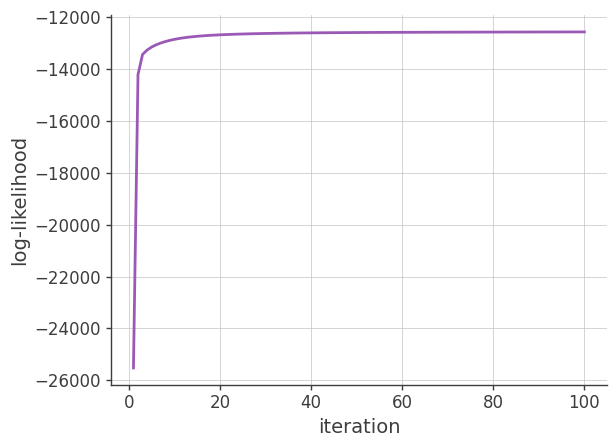

In [54]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['log-likelihood'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("log-likelihood")
plt.show()

### Alpha (the factor used for the acceleration)

Plotting $\alpha$ vs the number of iterations. $\alpha$ is a parameter to accelerate the EM algorithm (see the beginning of Section 4). If it is too large, reconstructed images may have artifacts.

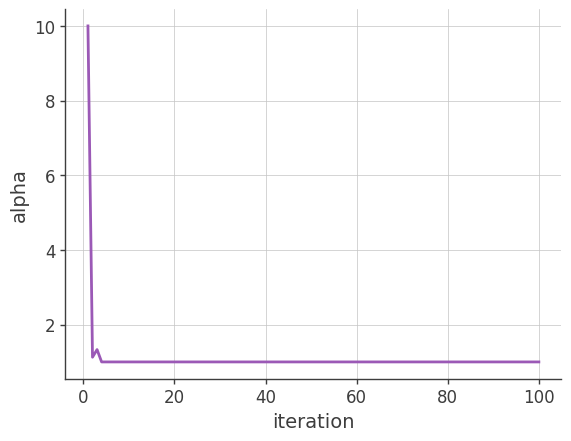

In [55]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['alpha'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("alpha")
plt.show()

### Background normalization

Plotting the background nomalization factor vs the number of iterations. If the background model is accurate and the image is reconstructed perfectly, this factor should be close to 1.

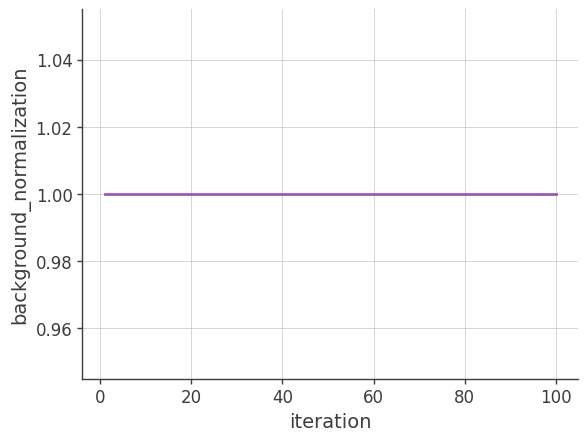

In [56]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['background_normalization']['albedo'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("background_normalization")
plt.show()

### Flux

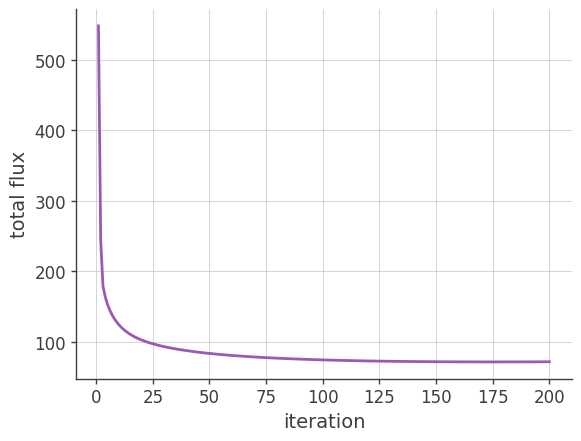

In [67]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append((np.sum(result['model']) * result['model'].axes['lb'].pixarea()).value)
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("total flux")
plt.show()

### The reconstructed images

In [68]:
def plot_reconstructed_image(result, source_position = None): # source_position should be (l,b) in degrees
    iteration = result['iteration']
    image = result['model']

    for energy_index in range(image.axes['Ei'].nbins):
        map_healpxmap = HealpixMap(data = image[:,energy_index], unit = image.unit)

        _, ax = map_healpxmap.plot('mollview')        
        
        _.colorbar.set_label(str(image.unit))
        
        if source_position is not None:
            ax.scatter(source_position[0]*u.deg, source_position[1]*u.deg, transform=ax.get_transform('world'), color = 'red')

        plt.title(label = f"iteration = {iteration}, energy_index = {energy_index} ({image.axes['Ei'].bounds[energy_index][0]}-{image.axes['Ei'].bounds[energy_index][1]})")

In [81]:
# tota flux

np.sum(image_deconvolution.results[-1]['model']) * image_deconvolution.results[-1]['model'].axes['lb'].pixarea()

<Quantity 71.58421395 1 / (s cm2)>

Plotting the reconstructed images in all of the energy bands at the 20th iteration

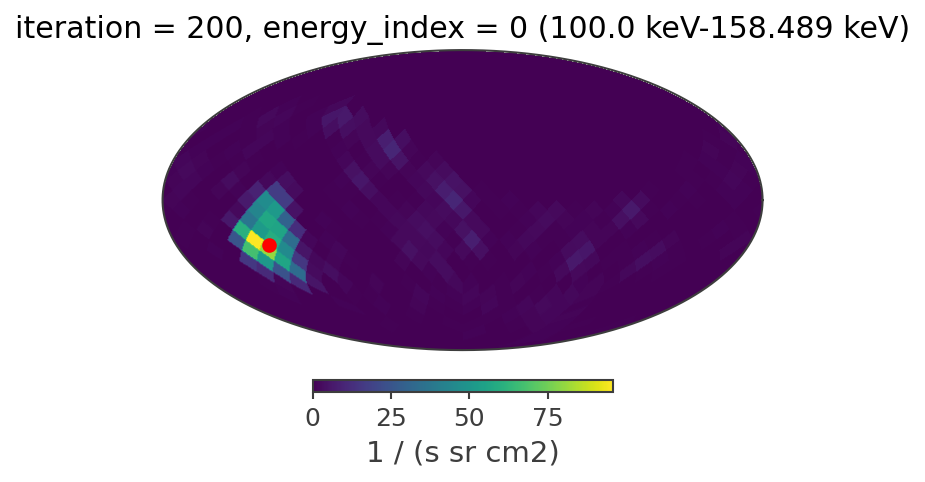

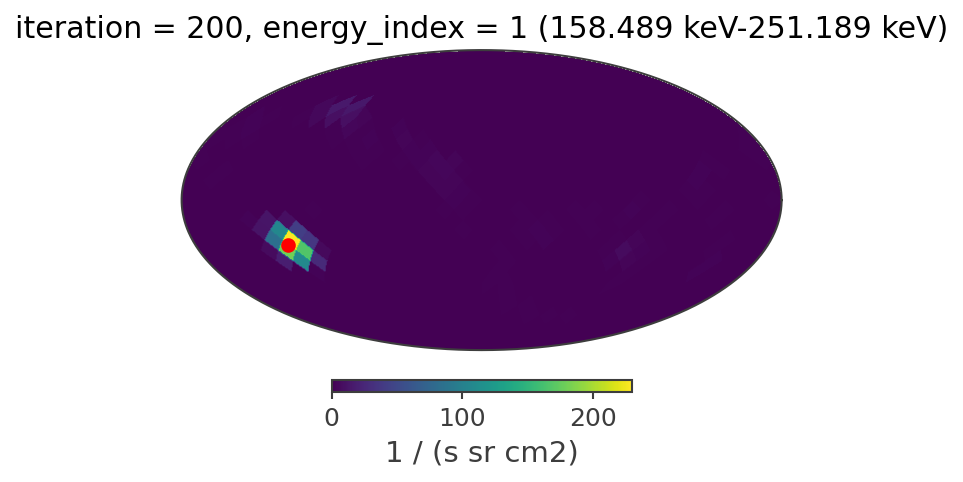

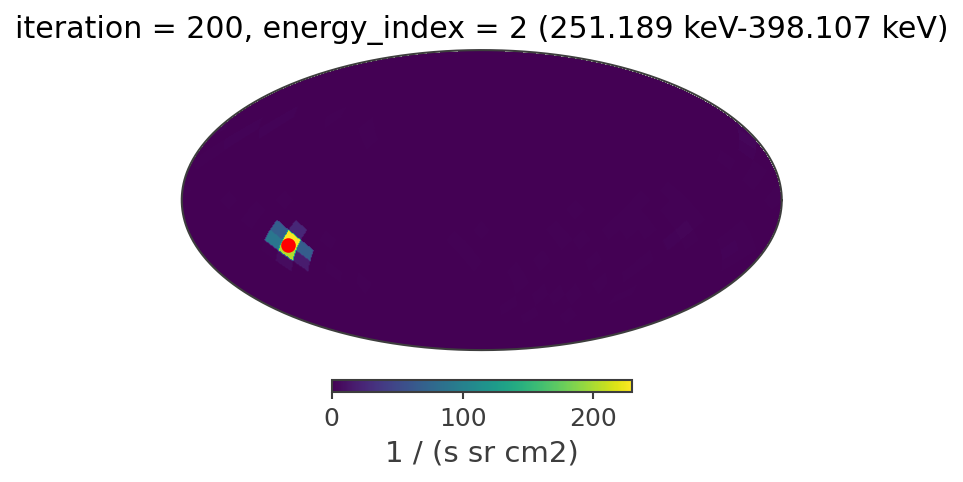

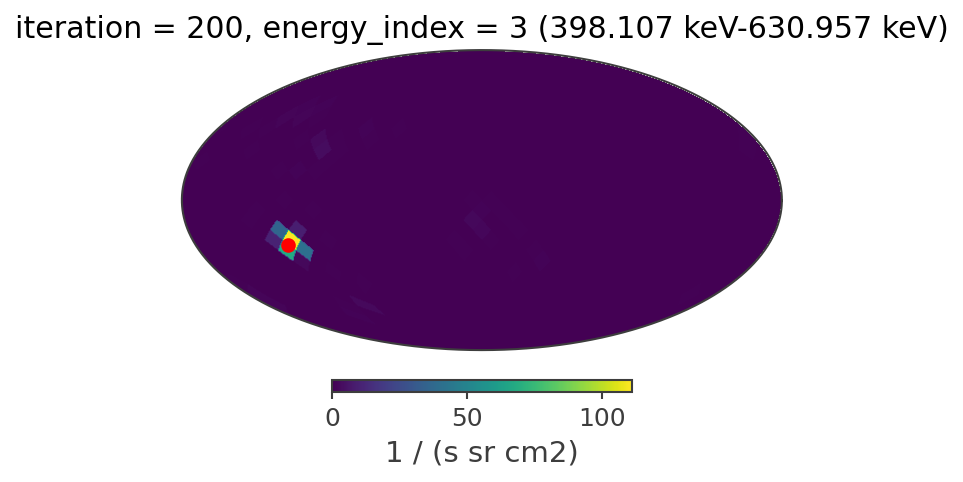

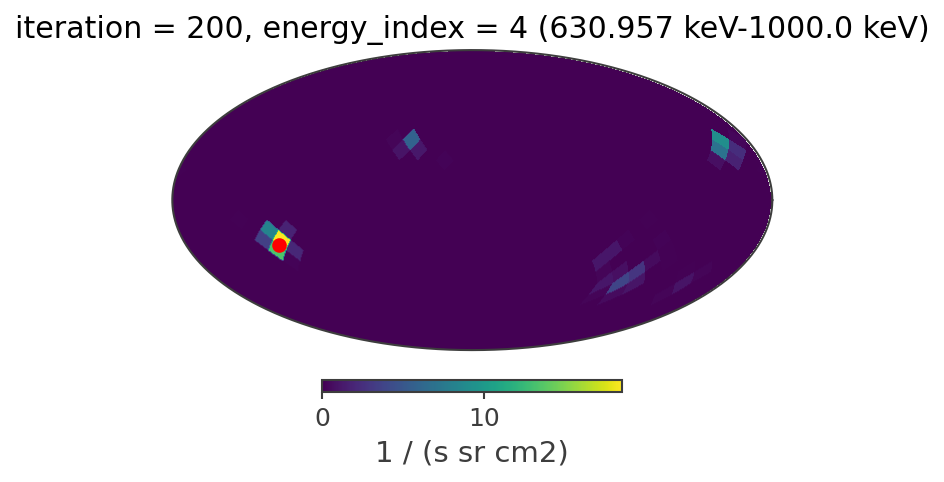

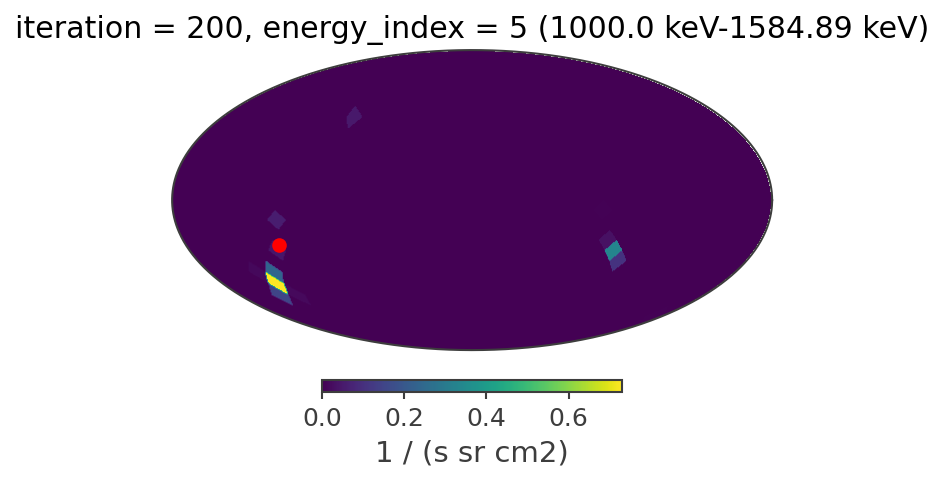

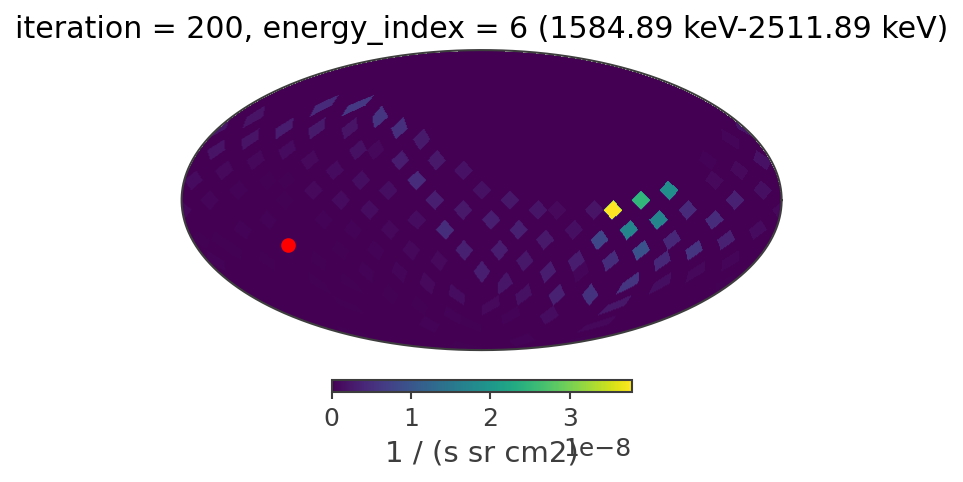

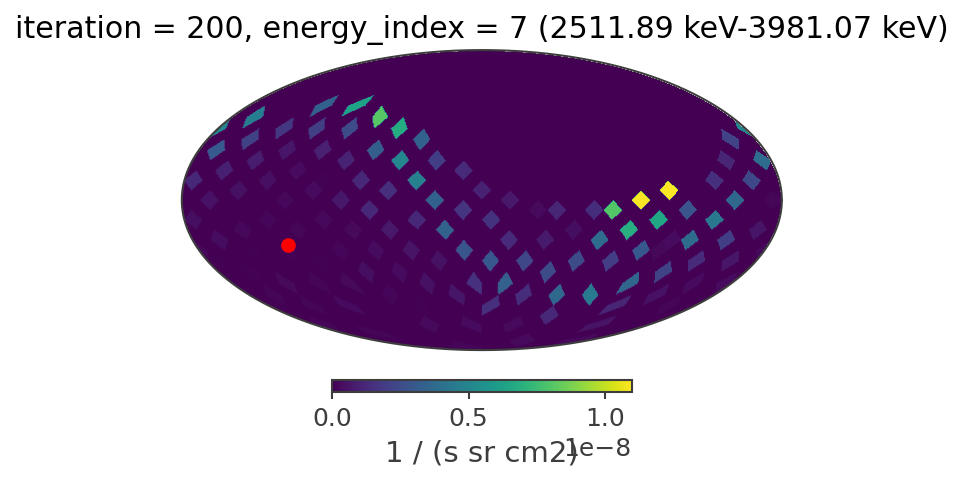

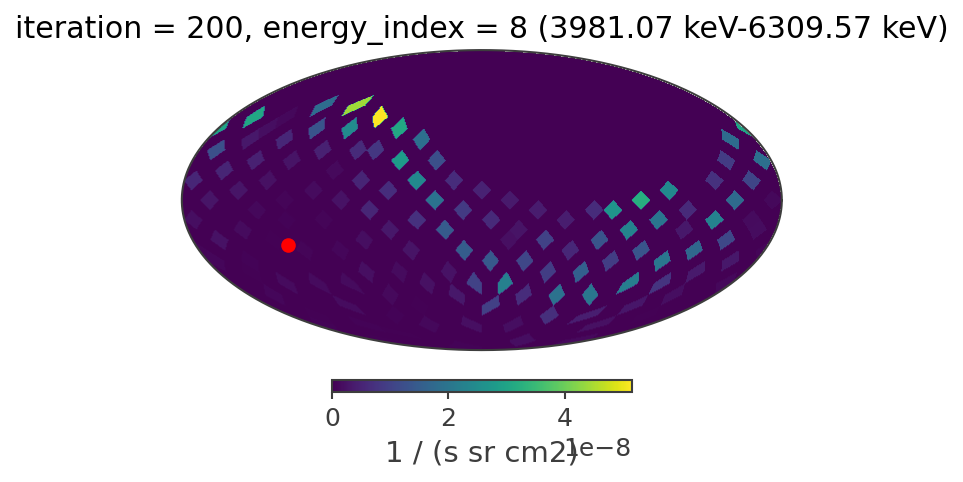

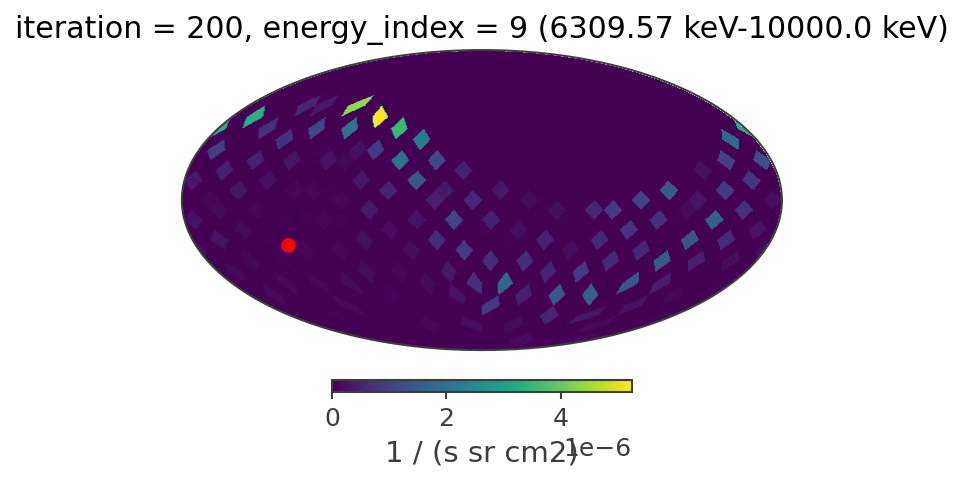

In [70]:
iteration = -1

plot_reconstructed_image(image_deconvolution.results[iteration], source_position = (121.17441, -21.5729))

**Note that above ~1MeV, there are few detected counts. Thus, the image above it looks wired with low flux.**